## **EDA**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving user_interactions.csv to user_interactions.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("user_interactions.csv")

df.info()         # information about the dataset
df.describe()     # summary statistics


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1488 entries, 0 to 1487
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   document_path  1488 non-null   object
 1   document_ID    1488 non-null   object
 2   chapter_id     1488 non-null   object
 3   is_correct     1488 non-null   int64 
 4   question_id    1488 non-null   int64 
 5   time_taken_ms  1488 non-null   int64 
 6   timestamp      1488 non-null   object
 7   user_email     1488 non-null   object
 8   user_uid       1488 non-null   object
 9   created_time   1488 non-null   object
 10  updated_time   1488 non-null   object
dtypes: int64(3), object(8)
memory usage: 128.0+ KB


,is_correct,question_id,time_taken_ms
count,1488.000000,1488.000000,1.488000e+03
mean,0.403898,114.276882,2.014246e+04
std,0.490842,95.940465,6.685313e+04
min,0.000000,1.000000,5.250000e+02
25%,0.000000,37.000000,1.616750e+03
50%,0.000000,68.000000,6.792500e+03
75%,1.000000,190.000000,1.917050e+04
max,1.000000,330.000000,1.779808e+06


### **Duplicate**

In [ ]:
df.duplicated().sum()


np.int64(0)

### **Missing Value**

In [ ]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
})
missing_table


,missing_count
document_path,0
document_ID,0
chapter_id,0
is_correct,0
question_id,0
time_taken_ms,0
timestamp,0
user_email,0
user_uid,0
created_time,0


### **Time Taken**

In [ ]:
Q1 = df['time_taken_ms'].quantile(0.25)
Q3 = df['time_taken_ms'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['time_taken_ms'] < lower_bound) | (df['time_taken_ms'] > upper_bound)]

print("Number of outliers:", len(outliers))


Number of outliers: 120


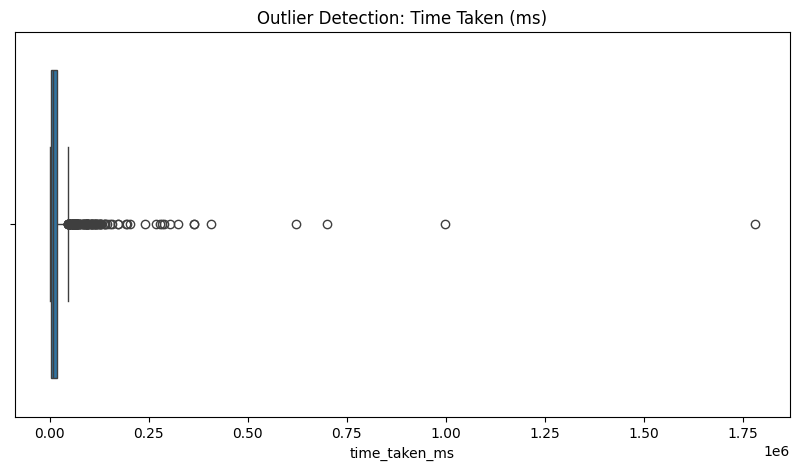

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['time_taken_ms'])
plt.title("Outlier Detection: Time Taken (ms)")
plt.show()


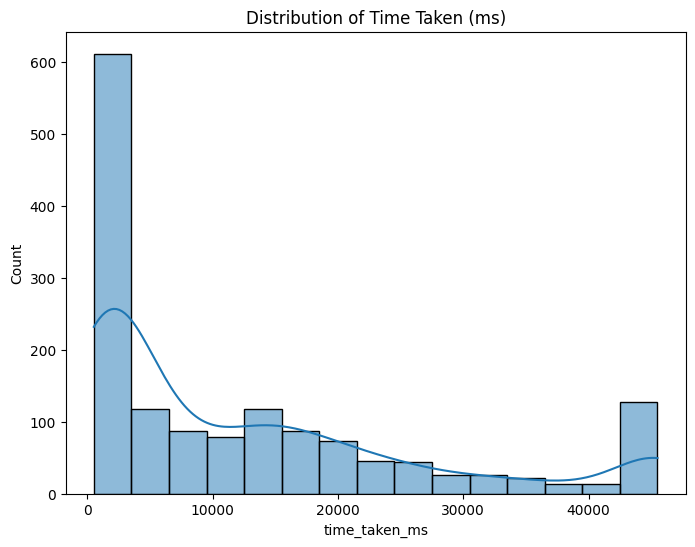

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['time_taken_ms'], kde=True)
plt.title("Distribution of Time Taken (ms)")
plt.show()


### **Chapter ID**

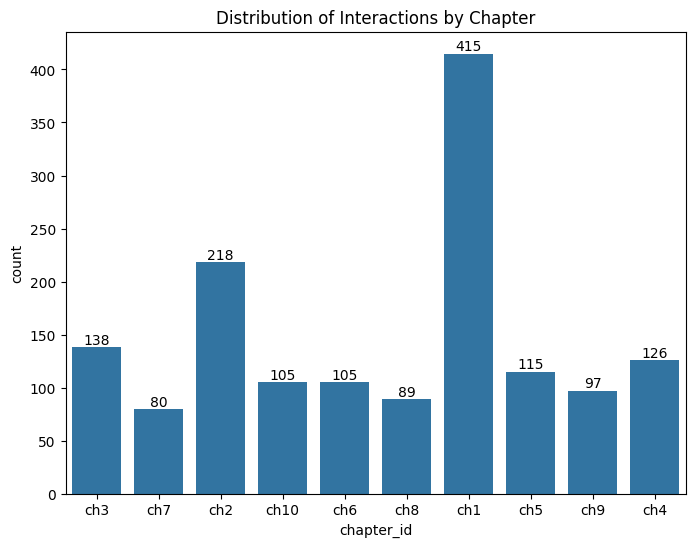

In [ ]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x=df['chapter_id'])

plt.title("Distribution of Interactions by Chapter")

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

### **User**

In [ ]:
# Number of attempts per user
attempts_table = df['user_uid'].value_counts().reset_index()
attempts_table.columns = ['user_uid', 'number_of_attempts']

# Summary statistics
attempts_table['number_of_attempts'].describe()

,number_of_attempts
count,86.000000
mean,17.302326
std,17.469348
min,1.000000
25%,5.000000
50%,10.000000
75%,21.750000
max,90.000000


In [ ]:
# count unique users per chapter
unique_users_per_chapter = df.groupby('chapter_id')['user_uid'].nunique()
avg_users = unique_users_per_chapter.mean()

print(f"average: {avg_users}\n")
print(unique_users_per_chapter)

average: 25.7

chapter_id
ch1     63
ch10    21
ch2     39
ch3     30
ch4     22
ch5     18
ch6     16
ch7     16
ch8     15
ch9     17
Name: user_uid, dtype: int64


### **Correctness**

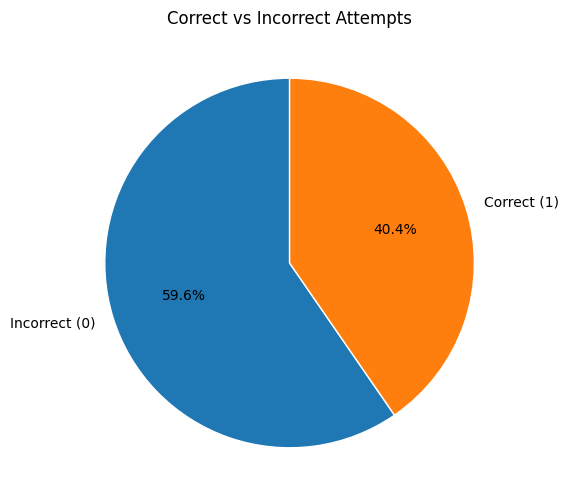

In [ ]:
import matplotlib.pyplot as plt

# Count the values
counts = df['is_correct'].value_counts()

# Labels for the pie chart
labels = ['Incorrect (0)', 'Correct (1)'] if 1 in counts.index else ['Value 0', 'Value 1']

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Correct vs Incorrect Attempts")
plt.show()


### **Correlation between time taken and correctness**

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df['time_taken_ms'])
y = df['is_correct']

model = sm.Logit(y, X).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.667585
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             is_correct   No. Observations:                 1488
Model:                          Logit   Df Residuals:                     1486
Method:                           MLE   Df Model:                            1
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                 0.01034
Time:                        05:20:53   Log-Likelihood:                -993.37
converged:                       True   LL-Null:                       -1003.7
Covariance Type:            nonrobust   LLR p-value:                 5.206e-06
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.5007      0.060     -8.325      0.000      -0.619      -0.383
time_taken_ms  6.003

## **Data Preprocessing**



### Drop Column

In [ ]:
df = df.drop(columns=['document_path', 'document_ID','created_time','updated_time','user_email'])

In [ ]:
df.head()

,chapter_id,is_correct,question_id,time_taken_ms,timestamp,user_uid
0,ch3,0,64,1300.0,12/10/2025 23:42,gxBpgEbVHlZxzNaRXnWlq2ZqGOi1
1,ch7,0,199,1023.0,4/20/2026 23:52,OwJh84A52Sg7uiM58TBo0dJSsjH3
2,ch2,0,60,1415.0,12/10/2025 22:15,lzbSt3k1QPby7Zuv8QlMI599fB72
3,ch10,0,293,1746.0,12/10/2025 21:54,Ic7MnqhIQTf9p8PswXCUWYK6Hwi2
4,ch6,0,181,1157.0,12/10/2025 22:55,JqboJ3Fj5qWmgeQrN9amPVsPnWB3


### Data Type Transformation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1488 entries, 0 to 1487
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   chapter_id     1488 non-null   object        
 1   is_correct     1488 non-null   int64         
 2   question_id    1488 non-null   int64         
 3   time_taken_ms  1488 non-null   float64       
 4   timestamp      1488 non-null   datetime64[ns]
 5   user_email     1488 non-null   object        
 6   user_uid       1488 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 81.5+ KB


In [ ]:
# 1. Convert timestamp to actual datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Convert IDs to categories so ML models don't treat them as math
categorical_cols = ['chapter_id', 'question_id', 'user_uid']
df[categorical_cols] = df[categorical_cols].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1488 entries, 0 to 1487
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   chapter_id     1488 non-null   category      
 1   is_correct     1488 non-null   int64         
 2   question_id    1488 non-null   category      
 3   time_taken_ms  1488 non-null   float64       
 4   timestamp      1488 non-null   datetime64[ns]
 5   user_email     1488 non-null   object        
 6   user_uid       1488 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 66.1+ KB


### Handle Outlier

In [ ]:
df['time_taken_ms'] = df['time_taken_ms'].clip(lower_bound, upper_bound)


In [ ]:
Q1 = df['time_taken_ms'].quantile(0.25)
Q3 = df['time_taken_ms'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['time_taken_ms'] < lower_bound) | (df['time_taken_ms'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


# **Download Cleaned Dataset**

In [ ]:
df.to_csv("cleaned_user_interactions.csv", index=False)

from google.colab import files
files.download("cleaned_user_interactions.csv")

NameError: name 'df' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_user_interactions.csv")

# **Model Training**

Import and Setup

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, mean_squared_error

# Set random seeds for reproducibility across all models
np.random.seed(42)
torch.manual_seed(42)

Train Test Split

In [ ]:
from google.colab import files

dataset = files.upload()

In [ ]:
df = pd.read_csv("cleaned_user_interactions.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['user_uid', 'timestamp']).reset_index(drop=True)

master_df = df.copy()

In [ ]:
unique_users = master_df['user_uid'].unique()

# Split 7:3 for Training:Testing
train_val_users, test_users = train_test_split(unique_users, test_size=0.30, random_state=42)

# Filter the master dataframe
train_val_df = master_df[master_df['user_uid'].isin(train_val_users)].copy()
test_df = master_df[master_df['user_uid'].isin(test_users)].copy()

print(f"Train/Val: {len(train_val_users)} | Interactions: {len(train_val_df)}")
print(f"Test: {len(test_users)} | Interactions: {len(test_df)}")

Train/Val: 60 | Interactions: 1138
Test: 26 | Interactions: 350


In [ ]:
# DATA PREPARATION For BKT and IRT-BKT
bkt_df = train_val_df.copy()

# Rename columns to match pyBKT requirements
bkt_df = bkt_df.rename(columns={
    'user_uid': 'user_id',
    'chapter_id': 'skill_name',
    'is_correct': 'correct',
    'question_id': 'item_id' # For IRT-BKT
})

irt_bkt_df = bkt_df.copy()


## pyBKT

In [ ]:
!pip install pyBKT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyBKT: filename=pyBKT-1.4.2-cp312-cp312-linux_x86_64.whl size=1130553 sha256=2eaefcaf25d99621aa58331c70aeff0454c5acdf48b0b85a14eb8675403a4130
  Stored in directory: /root/.cache/pip/wheels/86/91/2f/0eb4389642bed5183ec3d8d025ef7ff02099f08dafb9e0cc19
Successfully built pyBKT


### BKT

In [ ]:
from pyBKT.models import Model

print("Running 3-Fold Cross-Validation for Standard BKT...")
bkt_model = Model(seed=42, num_fits=5)

# Built-in Cross Validation
bkt_cv_results = bkt_model.crossvalidate(
    data=bkt_df,
    folds=3,
    metric=['auc', 'rmse']
)

# Extract Average Metrics
bkt_cv_auc = bkt_cv_results['auc'].mean()
bkt_cv_rmse = bkt_cv_results['rmse'].mean()

print(f"=== Standard BKT CV Results ===")
print(f"Average Validation AUC:  {bkt_cv_auc:.4f}")
print(f"Average Validation RMSE: {bkt_cv_rmse:.4f}\n")

Running 3-Fold Cross-Validation for Standard BKT...
=== Standard BKT CV Results ===
Average Validation AUC:  0.5232
Average Validation RMSE: 0.4761



In [ ]:
from pyBKT.models import Model

kf = KFold(n_splits=3, shuffle=True, random_state=42)
unique_users = bkt_df['user_id'].unique()

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(unique_users)):
    print(f"\n{'='*15} FOLD {fold+1} {'='*15}")

    train_users = unique_users[train_idx]
    val_users   = unique_users[val_idx]

    train_fold = bkt_df[bkt_df['user_id'].isin(train_users)]
    val_fold   = bkt_df[bkt_df['user_id'].isin(val_users)]

    # Train model on training fold
    bkt_model = Model(seed=42, num_fits=5)
    bkt_model.fit(data=train_fold)

    # --- Training performance ---
    train_preds = bkt_model.predict(data=train_fold)
    train_auc  = roc_auc_score(train_preds['correct'], train_preds['correct_predictions'])
    train_rmse = np.sqrt(mean_squared_error(train_preds['correct'], train_preds['correct_predictions']))

    # --- Validation performance ---
    val_preds = bkt_model.predict(data=val_fold)
    val_auc  = roc_auc_score(val_preds['correct'], val_preds['correct_predictions'])
    val_rmse = np.sqrt(mean_squared_error(val_preds['correct'], val_preds['correct_predictions']))

    print(f"Trn AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | Trn RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

    fold_results.append({
        'train_auc': train_auc, 'val_auc': val_auc,
        'train_rmse': train_rmse, 'val_rmse': val_rmse
    })

# Print Result
print(f"\n=== Standard BKT Results ===")
print(f"Avg Train AUC:  {np.mean([r['train_auc']  for r in fold_results]):.4f}")
print(f"Avg Val AUC:    {np.mean([r['val_auc']    for r in fold_results]):.4f}")
print(f"Avg Train RMSE: {np.mean([r['train_rmse'] for r in fold_results]):.4f}")
print(f"Avg Val RMSE:   {np.mean([r['val_rmse']   for r in fold_results]):.4f}")


=============== FOLD 1 ===============
Trn AUC: 0.6408 | Val AUC: 0.5689 | Trn RMSE: 0.4716 | Val RMSE: 0.4831

=============== FOLD 2 ===============
Trn AUC: 0.6517 | Val AUC: 0.5245 | Trn RMSE: 0.4679 | Val RMSE: 0.4931

=============== FOLD 3 ===============
Trn AUC: 0.6486 | Val AUC: 0.5939 | Trn RMSE: 0.4672 | Val RMSE: 0.4830

=== Standard BKT Results ===
Avg Train AUC:  0.6470
Avg Val AUC:    0.5624
Avg Train RMSE: 0.4689
Avg Val RMSE:   0.4864


### IRT-BKT

In [ ]:
from pyBKT.models import Model

# CROSS-VALIDATION
irt_bkt_model = Model(seed=42, num_fits=5)

irt_bkt_results = irt_bkt_model.crossvalidate(
    data=irt_bkt_df,
    folds=3, # 3 folds
    multigs=True,  # turns on the Item Response Theory logic
    # calculate a unique Guess and Slip rate for every single question (item)
    defaults={'multigs': 'item_id'},
    metric=['auc', 'rmse']
)

# Calculate the averages
irt_bkt_cv_auc = irt_bkt_results['auc'].mean()
irt_bkt_cv_rmse = irt_bkt_results['rmse'].mean()

print(f"=== IRT-BKT CV Results ===")
print(f"Average Validation AUC:  {irt_bkt_cv_auc:.4f}")
print(f"Average Validation RMSE: {irt_bkt_cv_rmse:.4f}\n")

=== IRT-BKT CV Results ===
Average Validation AUC:  0.5499
Average Validation RMSE: 0.5484



##pyKT

1. Setup and Installation

In [ ]:
# Clone pyKT repository
!git clone https://github.com/pykt-team/pykt-toolkit.git

Cloning into 'pykt-toolkit'...
remote: Enumerating objects: 7805, done.
remote: Counting objects: 100% (947/947), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 7805 (delta 910), reused 906 (delta 887), pack-reused 6858 (from 3)
Receiving objects: 100% (7805/7805), 39.24 MiB | 15.68 MiB/s, done.
Resolving deltas: 100% (6024/6024), done.


2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, mean_squared_error

import matplotlib.pyplot as plt
import sys

sys.path.append('/content/pykt-toolkit')
from pykt.models.simplekt import simpleKT
from pykt.models.cskt import CSKT

/content/pykt-toolkit/pykt/models/gkt.py:329: SyntaxWarning: invalid escape sequence '\m'
  this gate is different with that of the DKVMN. We used the input matrix to build the erase and add gates, rather than $\mathbf{v}_{t}$ vector in the DKVMN.
/content/pykt-toolkit/pykt/models/folibikt.py:592: SyntaxWarning: invalid escape sequence '\T'
  * `base` is the constant used for calculating $\Theta$
/content/pykt-toolkit/pykt/models/stablekt.py:592: SyntaxWarning: invalid escape sequence '\T'
  * `base` is the constant used for calculating $\Theta$
/content/pykt-toolkit/pykt/models/extrakt.py:574: SyntaxWarning: invalid escape sequence '\T'
  * `base` is the constant used for calculating $\Theta$


3. Data Loading and Preprocessing

In [ ]:
# 1. Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Get all unique question and chapter IDs
unique_questions = master_df['question_id'].unique()
unique_chapters = master_df['chapter_id'].unique()

# 3. Convert original IDs into numerical IDs
q_mapping = {val: i+1 for i, val in enumerate(unique_questions)}
c_mapping = {val: i+1 for i, val in enumerate(unique_chapters)}

# Total number of questions and chapters
num_q = len(unique_questions) + 1
num_c = len(unique_chapters) + 1


# 4. Replace original IDs with mapped numerical IDs
train_val_df['q_id'] = train_val_df['question_id'].map(q_mapping)
train_val_df['c_id'] = train_val_df['chapter_id'].map(c_mapping)
# Convert correctness to integer (0 or 1)
train_val_df['r_id'] = train_val_df['is_correct'].astype(int)

test_df['q_id'] = test_df['question_id'].map(q_mapping)
test_df['c_id'] = test_df['chapter_id'].map(c_mapping)
test_df['r_id'] = test_df['is_correct'].astype(int)

# 5. Group train/validation data by student
train_val_users_kt = train_val_df.groupby('user_uid').apply(
    lambda x: (x['q_id'].values, x['c_id'].values, x['r_id'].values)
).values

# 6. Group test data by student
test_users_kt = test_df.groupby('user_uid').apply(
    lambda x: (x['q_id'].values, x['c_id'].values, x['r_id'].values)
).values

print(f"Total Questions: {num_q} | Total Concepts: {num_c}")
print(f"CSKT Train/Val Sequences Ready: {len(train_val_users_kt)}")
print(f"CSKT Holdout Test Sequences Ready: {len(test_users_kt)}")

Total Questions: 312 | Total Concepts: 11
CSKT Train/Val Sequences Ready: 60
CSKT Holdout Test Sequences Ready: 26


/tmp/ipykernel_1796/3946815326.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_val_users_kt = train_val_df.groupby('user_uid').apply(
/tmp/ipykernel_1796/3946815326.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_users_kt = test_df.groupby('user_uid').apply(


4. Dataset Class

In [ ]:
class KTDataset(Dataset):
    def __init__(self, sequences, seq_len=100):
        # Maximum sequence length
        self.seq_len = seq_len
        # Store processed data
        self.data = []

        # Loop through each student's sequence
        for q, c, r in sequences:
            length = len(q)

            # Skip when the sqeuences less than 2
            if length < 2:
                continue

            # Split long sequences into smaller chunks
            for i in range(0, length - 1, seq_len):
                end_idx = min(i + seq_len, length)
                # Extract chunk
                chunk_q = q[i:end_idx]
                chunk_c = c[i:end_idx]
                chunk_r = r[i:end_idx]
                # Save chunk
                self.data.append((chunk_q, chunk_c, chunk_r))

    # Return total number of chunks
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get one chunk
        q, c, r = self.data[idx]

        # Calculate padding length
        pad_len = self.seq_len - len(q)

        # Pad sequences with zeros
        q_pad = np.pad(q, (0, pad_len), 'constant', constant_values=0)
        c_pad = np.pad(c, (0, pad_len), 'constant', constant_values=0)
        r_pad = np.pad(r, (0, pad_len), 'constant', constant_values=0)

        # Create input and target sequences
        qseqs, shft_qseqs = q_pad[:-1], q_pad[1:]
        cseqs, shft_cseqs = c_pad[:-1], c_pad[1:]
        rseqs, shft_rseqs = r_pad[:-1], r_pad[1:]

        return {
            "qseqs": torch.tensor(qseqs, dtype=torch.long),
            "cseqs": torch.tensor(cseqs, dtype=torch.long),
            "rseqs": torch.tensor(rseqs, dtype=torch.long),
            "shft_qseqs": torch.tensor(shft_qseqs, dtype=torch.long),
            "shft_cseqs": torch.tensor(shft_cseqs, dtype=torch.long),
            "shft_rseqs": torch.tensor(shft_rseqs, dtype=torch.long)
        }

### CSKT

In [ ]:
# 1. Setup Cross-Validation
k_folds = 3
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

epochs = 10

# Store training and validation metrics
metrics = {
    'train_loss': {f: [] for f in range(k_folds)},
    'val_loss': {f: [] for f in range(k_folds)},
    'train_auc': {f: [] for f in range(k_folds)},
    'val_auc': {f: [] for f in range(k_folds)},
    'train_rmse': {f: [] for f in range(k_folds)},
    'val_rmse':   {f: [] for f in range(k_folds)}
}

In [ ]:
# Loop through each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_users_kt)):
    print(f"\n{'='*15} FOLD {fold+1} {'='*15}")

    # Split data into training and validation sets
    train_users_fold = train_val_users_kt[train_idx]
    val_users_fold   = train_val_users_kt[val_idx]

    # Create datasets
    train_dataset = KTDataset(train_users_fold, seq_len=100)
    val_dataset   = KTDataset(val_users_fold,   seq_len=100)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

    # Model configuration
    model = CSKT(
        n_question=num_c,
        n_pid=num_q,
        d_model=256,
        n_blocks=3,
        dropout=0.1
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss(reduction='none')

    # Loop through epochs
    for epoch in range(epochs):
        # ================= TRAINING =================
        model.train()
        train_total_loss = 0.0
        train_preds, train_targets = [], []

        # Loop through training batches
        for batch in train_loader:
            optimizer.zero_grad()

            # Move batch data from CPU to GPU
            dcur = {k: v.to(device) for k, v in batch.items()}

            # Forward pass to model as input
            # train=True tells the model it is in training mode
            preds, _, _ = model(dcur, train=True)

            # Create target sequence
            target    = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()

            # Create mask
            mask_seq  = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
            mask      = (mask_seq > 0).float()
            valid_mask = (mask_seq > 0).bool()

            # Calculate loss
            loss = criterion(preds, target)
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            train_total_loss += loss.item()

            # Store predictions and targets
            train_preds.extend(preds[valid_mask].detach().cpu().numpy())
            train_targets.extend(target[valid_mask].cpu().numpy())

        # Calculate validation metrics
        avg_train_loss = train_total_loss / len(train_loader)
        train_auc  = roc_auc_score(train_targets, train_preds)
        train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))  # added

        # Save training metrics
        metrics['train_loss'][fold].append(avg_train_loss)
        metrics['train_auc'][fold].append(train_auc)
        metrics['train_rmse'][fold].append(train_rmse)  # added

        # ================= VALIDATION PHASE =================
        model.eval()
        val_total_loss = 0.0
        val_preds, val_targets = [], []

        # Disable gradient calculation
        with torch.no_grad():
            for batch in val_loader:
                dcur = {k: v.to(device) for k, v in batch.items()}
                preds    = model(dcur, train=False)
                target   = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                mask_seq = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
                mask      = (mask_seq > 0).float()
                valid_mask = (mask_seq > 0).bool()

                loss = criterion(preds, target)
                loss = (loss * mask).sum() / mask.sum()
                val_total_loss += loss.item()

                val_preds.extend(preds[valid_mask].cpu().numpy())
                val_targets.extend(target[valid_mask].cpu().numpy())

        avg_val_loss = val_total_loss / len(val_loader)
        try:
            val_auc  = roc_auc_score(val_targets, val_preds)
            val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
        except ValueError:
            val_auc  = 0.5
            val_rmse = float('nan')

        metrics['val_loss'][fold].append(avg_val_loss)
        metrics['val_auc'][fold].append(val_auc)
        metrics['val_rmse'][fold].append(val_rmse)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Trn Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Trn AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | "
              f"Trn RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

Starting 3-Fold Cross Validation

=============== FOLD 1 ===============
model_name: cskt, emb_type: qid
Epoch 01/10 | Trn Loss: 0.6858 | Val Loss: 0.6964 | Trn AUC: 0.5201 | Val AUC: 0.5533 | Trn RMSE: 0.4963 | Val RMSE: 0.4994
Epoch 02/10 | Trn Loss: 0.6850 | Val Loss: 0.6507 | Trn AUC: 0.6211 | Val AUC: 0.6042 | Trn RMSE: 0.4946 | Val RMSE: 0.4788
Epoch 03/10 | Trn Loss: 0.6464 | Val Loss: 0.6570 | Trn AUC: 0.6242 | Val AUC: 0.6176 | Trn RMSE: 0.4767 | Val RMSE: 0.4820
Epoch 04/10 | Trn Loss: 0.6499 | Val Loss: 0.6509 | Trn AUC: 0.6242 | Val AUC: 0.6225 | Trn RMSE: 0.4785 | Val RMSE: 0.4789
Epoch 05/10 | Trn Loss: 0.6400 | Val Loss: 0.6428 | Trn AUC: 0.6412 | Val AUC: 0.6288 | Trn RMSE: 0.4736 | Val RMSE: 0.4747
Epoch 06/10 | Trn Loss: 0.6271 | Val Loss: 0.6421 | Trn AUC: 0.6614 | Val AUC: 0.6269 | Trn RMSE: 0.4672 | Val RMSE: 0.4740
Epoch 07/10 | Trn Loss: 0.6271 | Val Loss: 0.6397 | Trn AUC: 0.6641 | Val AUC: 0.6290 | Trn RMSE: 0.4671 | Val RMSE: 0.4727
Epoch 08/10 | Trn Loss: 0.6

Evaluation

In [ ]:
def plot_cv_results(metrics, epochs, title=''):
    actual_k_folds = len(metrics['train_loss'])

    avg_train_loss = np.mean([metrics['train_loss'][f][-epochs:] for f in range(actual_k_folds)], axis=0)
    avg_val_loss   = np.mean([metrics['val_loss'][f][-epochs:]   for f in range(actual_k_folds)], axis=0)
    avg_train_auc  = np.mean([metrics['train_auc'][f][-epochs:]  for f in range(actual_k_folds)], axis=0)
    avg_val_auc    = np.mean([metrics['val_auc'][f][-epochs:]    for f in range(actual_k_folds)], axis=0)
    avg_train_rmse = np.mean([metrics['train_rmse'][f][-epochs:] for f in range(actual_k_folds)], axis=0)
    avg_val_rmse   = np.mean([metrics['val_rmse'][f][-epochs:]   for f in range(actual_k_folds)], axis=0)

    best_val_loss_epoch = np.argmin(avg_val_loss) + 1
    best_val_loss       = np.min(avg_val_loss)
    best_val_auc_epoch  = np.argmax(avg_val_auc) + 1
    best_val_auc        = np.max(avg_val_auc)
    best_val_rmse_epoch = np.argmin(avg_val_rmse) + 1
    best_val_rmse       = np.min(avg_val_rmse)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    if title:
        fig.suptitle(title)

    # ---- Plot 1: Loss ----
    ax1.plot(range(1, epochs+1), avg_train_loss, marker='o', label='Train Loss', color='blue')
    ax1.plot(range(1, epochs+1), avg_val_loss,   marker='o', label='Val Loss',   color='red')
    ax1.plot(best_val_loss_epoch, best_val_loss, 'go', label='Best Val Loss')
    ax1.axvline(best_val_loss_epoch, linestyle='--', color='green', alpha=0.6)
    ax1.annotate(f'{best_val_loss:.4f}', (best_val_loss_epoch, best_val_loss),
                 textcoords='offset points', xytext=(0,10), ha='center', color='green')
    ax1.set_title('Average Loss (Train vs Validation)')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
    ax1.grid(True); ax1.legend()

    # ---- Plot 2: AUC ----
    ax2.plot(range(1, epochs+1), avg_train_auc, marker='o', label='Train AUC', color='blue')
    ax2.plot(range(1, epochs+1), avg_val_auc,   marker='o', label='Val AUC',   color='red')
    ax2.plot(best_val_auc_epoch, best_val_auc, 'go', label='Best Val AUC')
    ax2.axvline(best_val_auc_epoch, linestyle='--', color='green', alpha=0.6)
    ax2.annotate(f'{best_val_auc:.4f}', (best_val_auc_epoch, best_val_auc),
                 textcoords='offset points', xytext=(0,10), ha='center', color='green')
    ax2.set_title('Average AUC (Train vs Validation)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC Score')
    ax2.grid(True); ax2.legend()

    # ---- Plot 3: RMSE ----  (added)
    ax3.plot(range(1, epochs+1), avg_train_rmse, marker='o', label='Train RMSE', color='blue')
    ax3.plot(range(1, epochs+1), avg_val_rmse,   marker='o', label='Val RMSE',   color='red')
    ax3.plot(best_val_rmse_epoch, best_val_rmse, 'go', label='Best Val RMSE')
    ax3.axvline(best_val_rmse_epoch, linestyle='--', color='green', alpha=0.6)
    ax3.annotate(f'{best_val_rmse:.4f}', (best_val_rmse_epoch, best_val_rmse),
                 textcoords='offset points', xytext=(0,10), ha='center', color='green')
    ax3.set_title('Average RMSE (Train vs Validation)')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('RMSE')
    ax3.grid(True); ax3.legend()

    plt.tight_layout()
    plt.show()

    print(f'Best Avg Validation Loss: {best_val_loss:.4f} at epoch {best_val_loss_epoch}')
    print(f'Best Avg Validation AUC : {best_val_auc:.4f} at epoch {best_val_auc_epoch}')
    print(f'Best Avg Validation RMSE: {best_val_rmse:.4f} at epoch {best_val_rmse_epoch}')

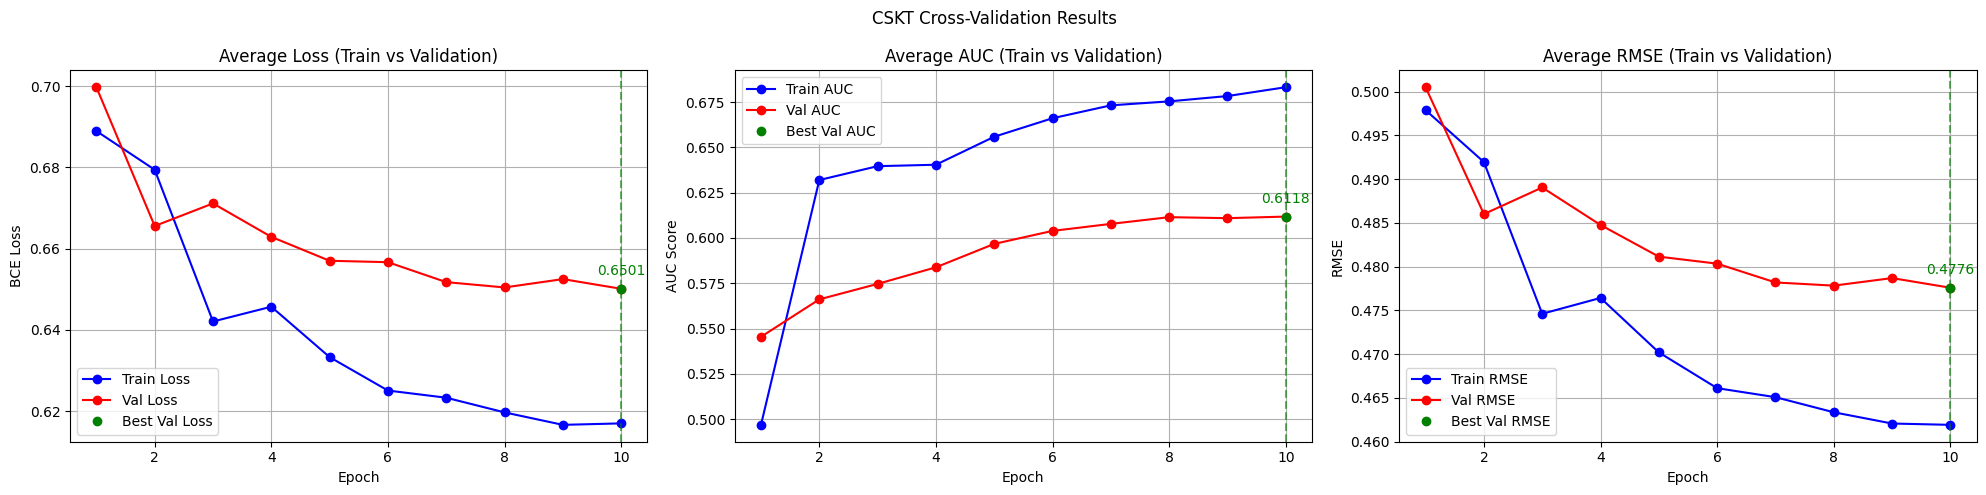

Best Avg Validation Loss: 0.6501 at epoch 10
Best Avg Validation AUC : 0.6118 at epoch 10
Best Avg Validation RMSE: 0.4776 at epoch 10


In [ ]:
plot_cv_results(metrics, epochs, title="CSKT Cross-Validation Results")

### SIMPLEKT

In [ ]:
# 1. Setup Cross-Validation
k_folds = 3
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

epochs = 10

# Store training and validation metrics
metrics = {
    'train_loss': {f: [] for f in range(k_folds)},
    'val_loss': {f: [] for f in range(k_folds)},
    'train_auc': {f: [] for f in range(k_folds)},
    'val_auc': {f: [] for f in range(k_folds)},
    'train_rmse': {f: [] for f in range(k_folds)},
    'val_rmse':   {f: [] for f in range(k_folds)}
}

In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_users_kt)):
    print(f"\n{'='*15} FOLD {fold+1} {'='*15}")

    # Creaye training and validation dataset
    train_users, val_users = train_val_users_kt[train_idx], train_val_users_kt[val_idx]

    # Create data loaders
    train_loader = DataLoader(KTDataset(train_users, seq_len=100), batch_size=64, shuffle=True)
    val_loader   = DataLoader(KTDataset(val_users,   seq_len=100), batch_size=64, shuffle=False)

    model = simpleKT(
        n_question=num_c,
        n_pid=num_q,
        d_model=256,
        n_blocks=3,
        dropout=0.1
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss(reduction='none')

    for epoch in range(epochs):
        # ================= TRAINING PHASE =================
        model.train()
        train_total_loss = 0.0
        train_preds, train_targets = [], []

        for batch in train_loader:
            optimizer.zero_grad()
            dcur = {k: v.to(device) for k, v in batch.items()}

            preds, _, _ = model(dcur, train=True)
            target     = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
            mask_seq   = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
            mask       = (mask_seq > 0).float()
            valid_mask = (mask_seq > 0).bool()

            # Calculate loss
            loss = criterion(preds, target)
            loss = (loss * mask).sum() / mask.sum()

            # Backpropagation
            loss.backward()
            optimizer.step()

            # Store loss
            train_total_loss += loss.item()

            # Store predictions and targets
            train_preds.extend(preds[valid_mask].detach().cpu().numpy())
            train_targets.extend(target[valid_mask].cpu().numpy())

        # Calculate training metrics
        avg_train_loss = train_total_loss / len(train_loader)
        train_auc  = roc_auc_score(train_targets, train_preds)
        train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))

        # Save training metrics
        metrics['train_loss'][fold].append(avg_train_loss)
        metrics['train_auc'][fold].append(train_auc)
        metrics['train_rmse'][fold].append(train_rmse)

        # ================= VALIDATION PHASE =================
        model.eval()
        val_total_loss = 0.0
        val_preds, val_targets = [], []

         # Disable gradient calculation
        with torch.no_grad():
            for batch in val_loader:
                dcur = {k: v.to(device) for k, v in batch.items()}

                preds      = model(dcur, train=False)
                target     = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                mask_seq   = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
                mask       = (mask_seq > 0).float()
                valid_mask = (mask_seq > 0).bool()

                loss = criterion(preds, target)
                loss = (loss * mask).sum() / mask.sum()
                val_total_loss += loss.item()

                val_preds.extend(preds[valid_mask].cpu().numpy())
                val_targets.extend(target[valid_mask].cpu().numpy())

        avg_val_loss = val_total_loss / len(val_loader)
        try:
            val_auc  = roc_auc_score(val_targets, val_preds)
            val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
        except ValueError:
            val_auc  = 0.5
            val_rmse = float('nan')

        metrics['val_loss'][fold].append(avg_val_loss)
        metrics['val_auc'][fold].append(val_auc)
        metrics['val_rmse'][fold].append(val_rmse)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Trn Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Trn AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | "
              f"Trn RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")


=============== FOLD 1 ===============
model_name: simplekt, emb_type: qid
Epoch 01/10 | Trn Loss: 0.6942 | Val Loss: 0.6989 | Trn AUC: 0.4642 | Val AUC: 0.5416 | Trn RMSE: 0.5005 | Val RMSE: 0.5005
Epoch 02/10 | Trn Loss: 0.6927 | Val Loss: 0.6592 | Trn AUC: 0.5976 | Val AUC: 0.5867 | Trn RMSE: 0.4980 | Val RMSE: 0.4830
Epoch 03/10 | Trn Loss: 0.6530 | Val Loss: 0.6631 | Trn AUC: 0.6137 | Val AUC: 0.5986 | Trn RMSE: 0.4801 | Val RMSE: 0.4849
Epoch 04/10 | Trn Loss: 0.6541 | Val Loss: 0.6611 | Trn AUC: 0.6162 | Val AUC: 0.6060 | Trn RMSE: 0.4805 | Val RMSE: 0.4839
Epoch 05/10 | Trn Loss: 0.6484 | Val Loss: 0.6529 | Trn AUC: 0.6282 | Val AUC: 0.6140 | Trn RMSE: 0.4777 | Val RMSE: 0.4798
Epoch 06/10 | Trn Loss: 0.6401 | Val Loss: 0.6467 | Trn AUC: 0.6379 | Val AUC: 0.6205 | Trn RMSE: 0.4737 | Val RMSE: 0.4765
Epoch 07/10 | Trn Loss: 0.6328 | Val Loss: 0.6424 | Trn AUC: 0.6546 | Val AUC: 0.6294 | Trn RMSE: 0.4700 | Val RMSE: 0.4741
Epoch 08/10 | Trn Loss: 0.6293 | Val Loss: 0.6381 | Trn 

Evaluation Function

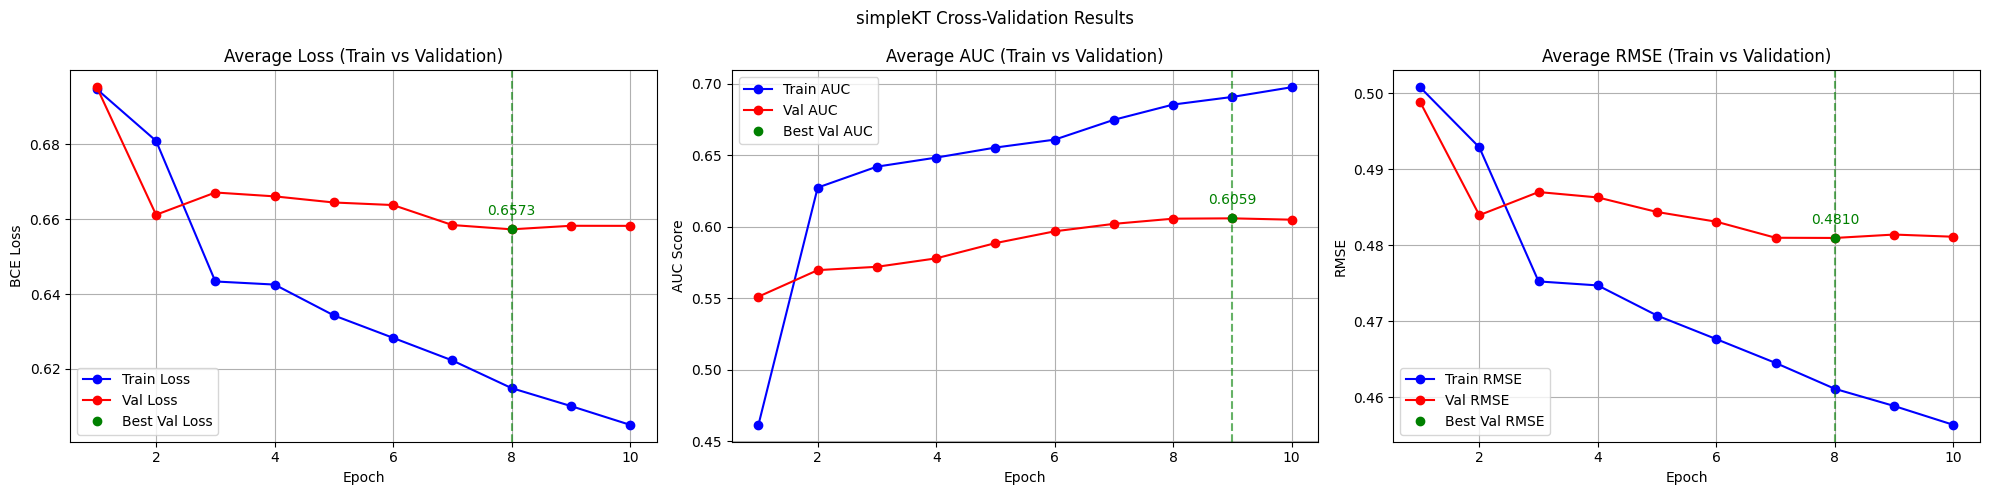

Best Avg Validation Loss: 0.6573 at epoch 8
Best Avg Validation AUC : 0.6059 at epoch 9
Best Avg Validation RMSE: 0.4810 at epoch 8


In [ ]:
plot_cv_results(metrics, epochs, title="simpleKT Cross-Validation Results")

# **Model Tuning**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.6 MB/s eta 0:00:00


In [ ]:
class EarlyStopping:
  # Initialize early stopping settings
    def __init__(self, patience=3, min_delta=0.001):
        # Number of epochs to wait before stopping
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_auc):
       # Save first validation score
        if self.best_score is None:
            self.best_score = val_auc
        elif val_auc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            # Stop training if counter reaches patience limit
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_auc
            self.counter = 0

In [ ]:
import optuna

def objective(trial):
    # Hyperparameter search space
    learning_rate = trial.suggest_categorical("lr", [0.001, 0.002, 0.003, 0.005])
    weight_decay  = trial.suggest_categorical("weight_decay", [0.0001, 0.0002, 0.0003, 0.0005])
    dropout_rate   = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3, 0.4, 0.5])
    n_blocks       = trial.suggest_categorical("n_blocks", [1, 2, 3, 4])
    batch_size     = trial.suggest_categorical("batch_size", [4, 8, 16, 32])
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "SGD", "RMSprop"])

    # Cross-validation setup
    k_folds = 3
    epochs = 20
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_best_aucs = [] # store best AUC from each fold

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_users_kt)):
        train_users, val_users = train_val_users_kt[train_idx], train_val_users_kt[val_idx]
        train_loader = DataLoader(KTDataset(train_users, seq_len=100), batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(KTDataset(val_users,   seq_len=100), batch_size=batch_size, shuffle=False)

        model = CSKT(n_question=num_c, n_pid=num_q, d_model=256, n_blocks=n_blocks, dropout=dropout_rate).to(device)

        # Choose optimizer based on trial
        if optimizer_name == "AdamW":
            optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_name == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
        else:
            optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # Loss function (binary classification loss)
        criterion = nn.BCELoss(reduction='none')

        # Early stopping to avoid overfitting
        early_stopping = EarlyStopping(patience=3, min_delta=0.001)
        best_fold_auc = 0.0

        for epoch in range(epochs):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                dcur = {k: v.to(device) for k, v in batch.items()}
                preds, _, _ = model(dcur, train=True)
                target = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                mask_seq = torch.cat((dcur["cseqs"].narrow(1, 0, 1), dcur["shft_cseqs"]), dim=1)
                mask = (mask_seq > 0).float()
                loss = (criterion(preds, target) * mask).sum() / mask.sum()
                loss.backward()
                optimizer.step()

            model.eval()
            val_preds, val_targets = [], []
            with torch.no_grad():
                for batch in val_loader:
                    dcur = {k: v.to(device) for k, v in batch.items()}
                    preds = model(dcur, train=False)
                    target = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                    mask_seq = torch.cat((dcur["cseqs"].narrow(1, 0, 1), dcur["shft_cseqs"]), dim=1)
                    valid_mask = (mask_seq > 0).bool()
                    val_preds.extend(preds[valid_mask].cpu().numpy())
                    val_targets.extend(target[valid_mask].cpu().numpy())
            try:
                val_auc = roc_auc_score(val_targets, val_preds)
            except ValueError: val_auc = 0.5

            if val_auc > best_fold_auc: best_fold_auc = val_auc
            early_stopping(val_auc)
            if early_stopping.early_stop: break

        fold_best_aucs.append(best_fold_auc)

    return np.mean(fold_best_aucs)

In [ ]:
# Create an Optuna study and get the highest AUC score
study = optuna.create_study(direction="maximize")

# Run the optimization for a set number of trials
study.optimize(objective, n_trials=80)

print("\nOptimization Complete!")
print("Best hyperparameters found: ", study.best_params)
print("Best average CV AUC: ", study.best_value)

[I 2026-05-12 04:33:02,614] A new study created in memory with name: no-name-a9da3b05-3103-476f-a50f-879fbd66414e


model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3


[I 2026-05-12 04:33:20,044] Trial 0 finished with value: 0.49392064213345543 and parameters: {'lr': 0.005, 'weight_decay': 0.0001, 'dropout': 0.2, 'n_blocks': 3, 'batch_size': 16, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 0.49392064213345543.


EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3


[I 2026-05-12 04:33:26,596] Trial 1 finished with value: 0.5562165819076729 and parameters: {'lr': 0.001, 'weight_decay': 0.0005, 'dropout': 0.2, 'n_blocks': 3, 'batch_size': 32, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.5562165819076729.


...

EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3


[I 2026-05-12 04:37:12,354] Trial 78 finished with value: 0.6200355202268474 and parameters: {'lr': 0.001, 'weight_decay': 0.0003, 'dropout': 0.5, 'n_blocks': 3, 'batch_size': 16, 'optimizer': 'AdamW'}. Best is trial 22 with value: 0.6422593520272227.


EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: cskt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3


[I 2026-05-12 04:37:15,969] Trial 79 finished with value: 0.6265531186765513 and parameters: {'lr': 0.002, 'weight_decay': 0.0003, 'dropout': 0.5, 'n_blocks': 4, 'batch_size': 8, 'optimizer': 'AdamW'}. Best is trial 22 with value: 0.6422593520272227.


EarlyStopping counter: 3 out of 3

Optimization Complete!
Best hyperparameters found:  {'lr': 0.003, 'weight_decay': 0.0003, 'dropout': 0.5, 'n_blocks': 3, 'batch_size': 8, 'optimizer': 'AdamW'}
Best average CV AUC:  0.6422593520272227


Simple KT

In [ ]:
import optuna

def objective(trial):
    # Hyperparameter search space
    learning_rate = trial.suggest_categorical("lr", [0.001, 0.002, 0.003, 0.005])
    weight_decay  = trial.suggest_categorical("weight_decay", [0.0001, 0.0002, 0.0003, 0.0005])
    dropout_rate   = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3, 0.4, 0.5])
    n_blocks       = trial.suggest_categorical("n_blocks", [1, 2, 3, 4])
    batch_size     = trial.suggest_categorical("batch_size", [4, 8, 16, 32])
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "SGD", "RMSprop"])

    # Cross-validation setup
    k_folds = 3
    epochs = 20
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_best_aucs = [] # store best AUC from each fold

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_users_kt)):
        train_users, val_users = train_val_users_kt[train_idx], train_val_users_kt[val_idx]
        train_loader = DataLoader(KTDataset(train_users, seq_len=100), batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(KTDataset(val_users,   seq_len=100), batch_size=batch_size, shuffle=False)

        model = simpleKT(n_question=num_c, n_pid=num_q, d_model=256, n_blocks=n_blocks, dropout=dropout_rate).to(device)

        # Choose optimizer based on trial
        if optimizer_name == "AdamW":
            optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_name == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
        else:
            optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # Loss function (binary classification loss)
        criterion = nn.BCELoss(reduction='none')

        # Early stopping to avoid overfitting
        early_stopping = EarlyStopping(patience=3, min_delta=0.001)
        best_fold_auc = 0.0

        for epoch in range(epochs):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                dcur = {k: v.to(device) for k, v in batch.items()}
                preds, _, _ = model(dcur, train=True)
                target = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                mask_seq = torch.cat((dcur["cseqs"].narrow(1, 0, 1), dcur["shft_cseqs"]), dim=1)
                mask = (mask_seq > 0).float()
                loss = (criterion(preds, target) * mask).sum() / mask.sum()
                loss.backward()
                optimizer.step()

            model.eval()
            val_preds, val_targets = [], []
            with torch.no_grad():
                for batch in val_loader:
                    dcur = {k: v.to(device) for k, v in batch.items()}
                    preds = model(dcur, train=False)
                    target = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                    mask_seq = torch.cat((dcur["cseqs"].narrow(1, 0, 1), dcur["shft_cseqs"]), dim=1)
                    valid_mask = (mask_seq > 0).bool()
                    val_preds.extend(preds[valid_mask].cpu().numpy())
                    val_targets.extend(target[valid_mask].cpu().numpy())
            try:
                val_auc = roc_auc_score(val_targets, val_preds)
            except ValueError: val_auc = 0.5

            if val_auc > best_fold_auc: best_fold_auc = val_auc
            early_stopping(val_auc)
            if early_stopping.early_stop: break

        fold_best_aucs.append(best_fold_auc)

    return np.mean(fold_best_aucs)

In [ ]:
# Create an Optuna study and get the highest AUC score
study = optuna.create_study(direction="maximize")

# Run the optimization for a set number of trials
study.optimize(objective, n_trials=80)

print("\nOptimization Complete!")
print("Best hyperparameters found: ", study.best_params)
print("Best average CV AUC: ", study.best_value)

[I 2026-05-12 06:44:53,626] A new study created in memory with name: no-name-3a588ec8-c83b-41bd-9f57-24860fbc3d75


model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3


[I 2026-05-12 06:45:03,609] Trial 0 finished with value: 0.5950394651721602 and parameters: {'lr': 0.005, 'weight_decay': 0.0002, 'dropout': 0.4, 'n_blocks': 4, 'batch_size': 32, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.5950394651721602.


EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3


[I 2026-05-12 06:45:10,494] Trial 1 finished with value: 0.6141912875713231 and parameters: {'lr': 0.005, 'weight_decay': 0.0002, 'dropout': 0.2, 'n_blocks': 4, 'batch_size': 4, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.6141912875713231.


...

EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3


[I 2026-05-12 06:49:29,038] Trial 78 finished with value: 0.63044124707045 and parameters: {'lr': 0.001, 'weight_decay': 0.0002, 'dropout': 0.5, 'n_blocks': 3, 'batch_size': 4, 'optimizer': 'AdamW'}. Best is trial 53 with value: 0.6352027443764405.


EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3
model_name: simplekt, emb_type: qid
EarlyStopping counter: 1 out of 3
EarlyStopping counter: 1 out of 3


[I 2026-05-12 06:49:31,287] Trial 79 finished with value: 0.6223292595038892 and parameters: {'lr': 0.002, 'weight_decay': 0.0002, 'dropout': 0.5, 'n_blocks': 4, 'batch_size': 8, 'optimizer': 'AdamW'}. Best is trial 53 with value: 0.6352027443764405.


EarlyStopping counter: 2 out of 3
EarlyStopping counter: 3 out of 3

Optimization Complete!
Best hyperparameters found:  {'lr': 0.001, 'weight_decay': 0.0002, 'dropout': 0.5, 'n_blocks': 4, 'batch_size': 4, 'optimizer': 'AdamW'}
Best average CV AUC:  0.6352027443764405


## Model Training

### CSKT

In [ ]:
# Reset metrics for tuned CSKT training run
metrics = {
    'train_loss': {f: [] for f in range(k_folds)},
    'val_loss': {f: [] for f in range(k_folds)},
    'train_auc': {f: [] for f in range(k_folds)},
    'val_auc': {f: [] for f in range(k_folds)},
    'train_rmse': {f: [] for f in range(k_folds)},
    'val_rmse':   {f: [] for f in range(k_folds)}
}

In [ ]:
# Loop through each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_users_kt)):
    print(f"\n{'='*15} FOLD {fold+1} {'='*15}")

    # Split data into training and validation sets
    train_users_fold = train_val_users_kt[train_idx]
    val_users_fold   = train_val_users_kt[val_idx]

    # Create datasets
    train_dataset = KTDataset(train_users_fold, seq_len=100)
    val_dataset   = KTDataset(val_users_fold,   seq_len=100)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

    # Model configuration
    model = CSKT(
        n_question=num_c,
        n_pid=num_q,
        d_model=256,
        n_blocks=3,
        dropout=0.5).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=0.0003)
    criterion = nn.BCELoss(reduction='none')

    # Loop through epochs
    for epoch in range(epochs):
        # ================= TRAINING =================
        model.train()
        train_total_loss = 0.0
        train_preds, train_targets = [], []

        # Loop through training batches
        for batch in train_loader:
            optimizer.zero_grad()

            # Move batch data from CPU to GPU
            dcur = {k: v.to(device) for k, v in batch.items()}

            # Forward pass to model as input
            # train=True tells the model it is in training mode
            preds, _, _ = model(dcur, train=True)

            # Create target sequence
            target    = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()

            # Create mask
            mask_seq  = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
            mask      = (mask_seq > 0).float()
            valid_mask = (mask_seq > 0).bool()

            # Calculate loss
            loss = criterion(preds, target)
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            train_total_loss += loss.item()

            # Store predictions and targets
            train_preds.extend(preds[valid_mask].detach().cpu().numpy())
            train_targets.extend(target[valid_mask].cpu().numpy())

        # Calculate validation metrics
        avg_train_loss = train_total_loss / len(train_loader)
        train_auc  = roc_auc_score(train_targets, train_preds)
        train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))  # added

        # Save training metrics
        metrics['train_loss'][fold].append(avg_train_loss)
        metrics['train_auc'][fold].append(train_auc)
        metrics['train_rmse'][fold].append(train_rmse)  # added

        # ================= VALIDATION PHASE =================
        model.eval()
        val_total_loss = 0.0
        val_preds, val_targets = [], []

        # Disable gradient calculation
        with torch.no_grad():
            for batch in val_loader:
                dcur = {k: v.to(device) for k, v in batch.items()}
                preds    = model(dcur, train=False)
                target   = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                mask_seq = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
                mask      = (mask_seq > 0).float()
                valid_mask = (mask_seq > 0).bool()

                loss = criterion(preds, target)
                loss = (loss * mask).sum() / mask.sum()
                val_total_loss += loss.item()

                val_preds.extend(preds[valid_mask].cpu().numpy())
                val_targets.extend(target[valid_mask].cpu().numpy())

        avg_val_loss = val_total_loss / len(val_loader)
        try:
            val_auc  = roc_auc_score(val_targets, val_preds)
            val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
        except ValueError:
            val_auc  = 0.5
            val_rmse = float('nan')

        metrics['val_loss'][fold].append(avg_val_loss)
        metrics['val_auc'][fold].append(val_auc)
        metrics['val_rmse'][fold].append(val_rmse)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Trn Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Trn AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | "
              f"Trn RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")


=============== FOLD 1 ===============
model_name: cskt, emb_type: qid
Epoch 01/10 | Trn Loss: 0.7394 | Val Loss: 0.6803 | Trn AUC: 0.4717 | Val AUC: 0.5479 | Trn RMSE: 0.5187 | Val RMSE: 0.4937
Epoch 02/10 | Trn Loss: 0.6956 | Val Loss: 0.6763 | Trn AUC: 0.5018 | Val AUC: 0.5705 | Trn RMSE: 0.4949 | Val RMSE: 0.4917
Epoch 03/10 | Trn Loss: 0.6586 | Val Loss: 0.6566 | Trn AUC: 0.5951 | Val AUC: 0.5879 | Trn RMSE: 0.4831 | Val RMSE: 0.4824
Epoch 04/10 | Trn Loss: 0.6603 | Val Loss: 0.6522 | Trn AUC: 0.6102 | Val AUC: 0.6094 | Trn RMSE: 0.4803 | Val RMSE: 0.4796
Epoch 05/10 | Trn Loss: 0.6620 | Val Loss: 0.6462 | Trn AUC: 0.5930 | Val AUC: 0.6305 | Trn RMSE: 0.4852 | Val RMSE: 0.4767
Epoch 06/10 | Trn Loss: 0.6357 | Val Loss: 0.6405 | Trn AUC: 0.6411 | Val AUC: 0.6632 | Trn RMSE: 0.4742 | Val RMSE: 0.4715
Epoch 07/10 | Trn Loss: 0.6522 | Val Loss: 0.6359 | Trn AUC: 0.6406 | Val AUC: 0.6420 | Trn RMSE: 0.4745 | Val RMSE: 0.4720
Epoch 08/10 | Trn Loss: 0.6417 | Val Loss: 0.6354 | Trn AUC:

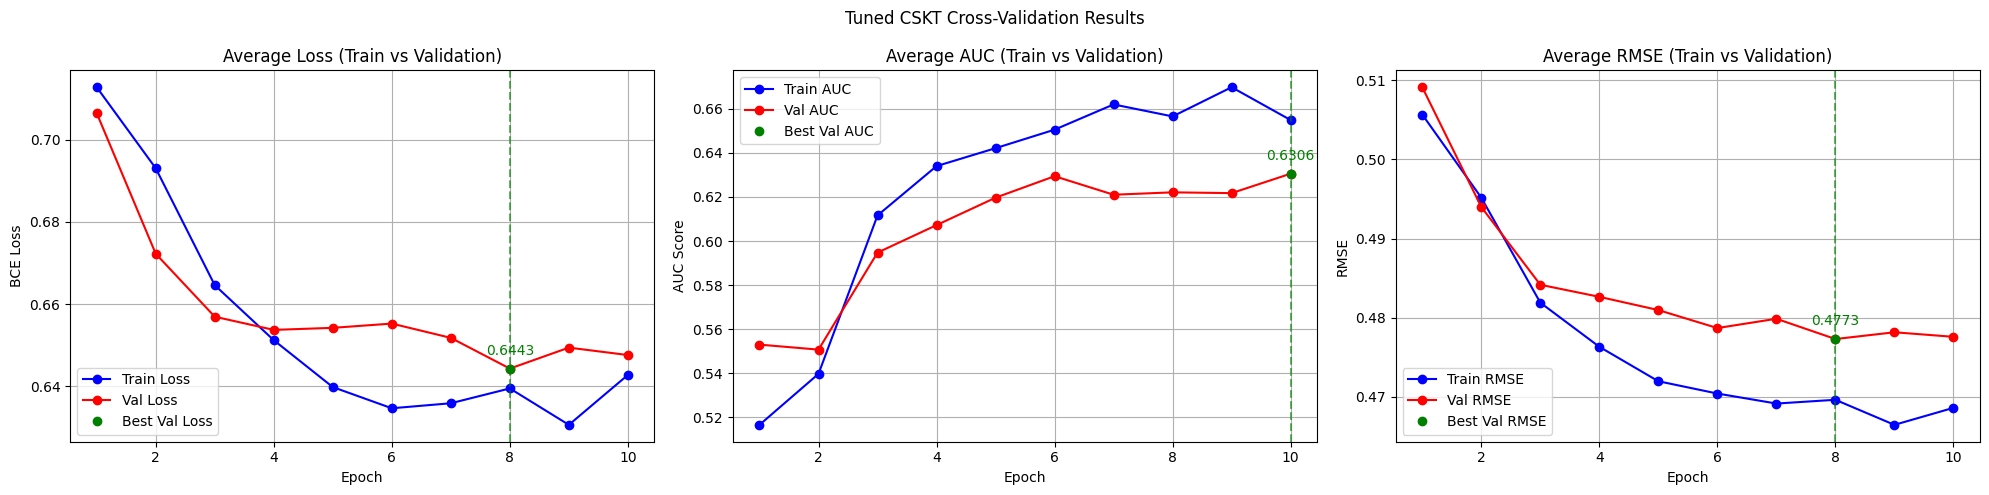

Best Avg Validation Loss: 0.6443 at epoch 8
Best Avg Validation AUC : 0.6306 at epoch 10
Best Avg Validation RMSE: 0.4773 at epoch 8


In [ ]:
plot_cv_results(metrics, epochs, title="Tuned CSKT Cross-Validation Results")

### SimpleKT

In [ ]:
# Reset metrics for tuned SimpleKT training run
metrics = {
    'train_loss': {f: [] for f in range(k_folds)},
    'val_loss': {f: [] for f in range(k_folds)},
    'train_auc': {f: [] for f in range(k_folds)},
    'val_auc': {f: [] for f in range(k_folds)},
    'train_rmse': {f: [] for f in range(k_folds)},
    'val_rmse':   {f: [] for f in range(k_folds)}
}

In [ ]:
# Loop through each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_users_kt)):
    print(f"\n{'='*15} FOLD {fold+1} {'='*15}")

    # Split data into training and validation sets
    train_users_fold = train_val_users_kt[train_idx]
    val_users_fold   = train_val_users_kt[val_idx]

    # Create datasets
    train_dataset = KTDataset(train_users_fold, seq_len=100)
    val_dataset   = KTDataset(val_users_fold,   seq_len=100)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

    # Model configuration
    model = simpleKT(
        n_question=num_c,
        n_pid=num_q,
        d_model=256,
        n_blocks=4,
        dropout=0.5).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0002)
    criterion = nn.BCELoss(reduction='none')

    # Loop through epochs
    for epoch in range(epochs):
        # ================= TRAINING =================
        model.train()
        train_total_loss = 0.0
        train_preds, train_targets = [], []

        # Loop through training batches
        for batch in train_loader:
            optimizer.zero_grad()

            # Move batch data from CPU to GPU
            dcur = {k: v.to(device) for k, v in batch.items()}

            # Forward pass to model as input
            # train=True tells the model it is in training mode
            preds, _, _ = model(dcur, train=True)

            # Create target sequence
            target    = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()

            # Create mask
            mask_seq  = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
            mask      = (mask_seq > 0).float()
            valid_mask = (mask_seq > 0).bool()

            # Calculate loss
            loss = criterion(preds, target)
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            train_total_loss += loss.item()

            # Store predictions and targets
            train_preds.extend(preds[valid_mask].detach().cpu().numpy())
            train_targets.extend(target[valid_mask].cpu().numpy())

        # Calculate validation metrics
        avg_train_loss = train_total_loss / len(train_loader)
        train_auc  = roc_auc_score(train_targets, train_preds)
        train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))  # added

        # Save training metrics
        metrics['train_loss'][fold].append(avg_train_loss)
        metrics['train_auc'][fold].append(train_auc)
        metrics['train_rmse'][fold].append(train_rmse)  # added

        # ================= VALIDATION PHASE =================
        model.eval()
        val_total_loss = 0.0
        val_preds, val_targets = [], []

        # Disable gradient calculation
        with torch.no_grad():
            for batch in val_loader:
                dcur = {k: v.to(device) for k, v in batch.items()}
                preds    = model(dcur, train=False)
                target   = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
                mask_seq = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
                mask      = (mask_seq > 0).float()
                valid_mask = (mask_seq > 0).bool()

                loss = criterion(preds, target)
                loss = (loss * mask).sum() / mask.sum()
                val_total_loss += loss.item()

                val_preds.extend(preds[valid_mask].cpu().numpy())
                val_targets.extend(target[valid_mask].cpu().numpy())

        avg_val_loss = val_total_loss / len(val_loader)
        try:
            val_auc  = roc_auc_score(val_targets, val_preds)
            val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
        except ValueError:
            val_auc  = 0.5
            val_rmse = float('nan')

        metrics['val_loss'][fold].append(avg_val_loss)
        metrics['val_auc'][fold].append(val_auc)
        metrics['val_rmse'][fold].append(val_rmse)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Trn Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Trn AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | "
              f"Trn RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")


=============== FOLD 1 ===============
model_name: simplekt, emb_type: qid
Epoch 01/10 | Trn Loss: 0.6975 | Val Loss: 0.6870 | Trn AUC: 0.4854 | Val AUC: 0.6434 | Trn RMSE: 0.4999 | Val RMSE: 0.4785
Epoch 02/10 | Trn Loss: 0.6427 | Val Loss: 0.6711 | Trn AUC: 0.6161 | Val AUC: 0.6435 | Trn RMSE: 0.4783 | Val RMSE: 0.4726
Epoch 03/10 | Trn Loss: 0.6469 | Val Loss: 0.6638 | Trn AUC: 0.6352 | Val AUC: 0.6601 | Trn RMSE: 0.4752 | Val RMSE: 0.4715
Epoch 04/10 | Trn Loss: 0.6524 | Val Loss: 0.6649 | Trn AUC: 0.6155 | Val AUC: 0.6474 | Trn RMSE: 0.4798 | Val RMSE: 0.4704
Epoch 05/10 | Trn Loss: 0.6524 | Val Loss: 0.6606 | Trn AUC: 0.6288 | Val AUC: 0.6574 | Trn RMSE: 0.4764 | Val RMSE: 0.4698
Epoch 06/10 | Trn Loss: 0.6346 | Val Loss: 0.6707 | Trn AUC: 0.6494 | Val AUC: 0.6666 | Trn RMSE: 0.4728 | Val RMSE: 0.4689
Epoch 07/10 | Trn Loss: 0.6416 | Val Loss: 0.6689 | Trn AUC: 0.6579 | Val AUC: 0.6662 | Trn RMSE: 0.4678 | Val RMSE: 0.4714
Epoch 08/10 | Trn Loss: 0.6448 | Val Loss: 0.6929 | Trn 

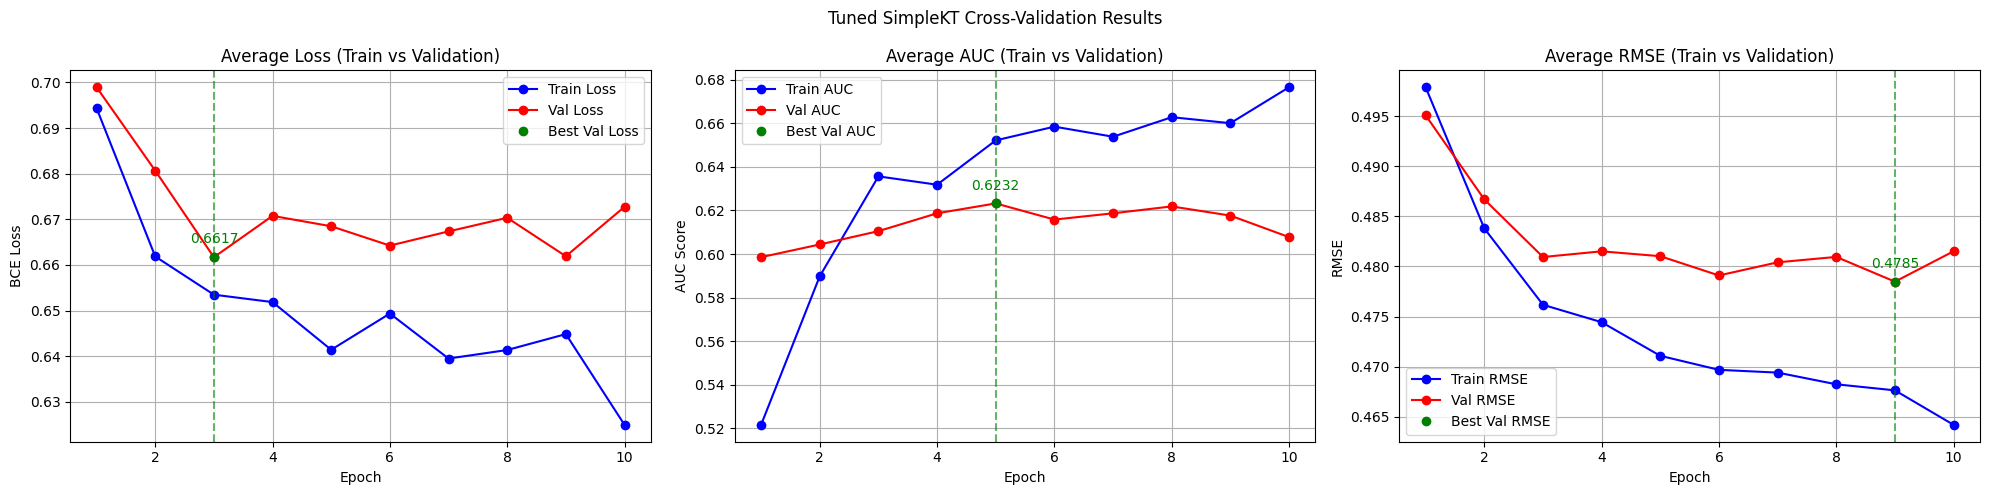

Best Avg Validation Loss: 0.6617 at epoch 3
Best Avg Validation AUC : 0.6232 at epoch 5
Best Avg Validation RMSE: 0.4785 at epoch 9


In [ ]:
plot_cv_results(metrics, epochs, title="Tuned SimpleKT Cross-Validation Results")

## Final Model Training

In [ ]:
# Create the training loader using the full 80% train_val_set with seq_len=100
train_val_loader = DataLoader(
    KTDataset(train_val_users_kt, seq_len=100),
    batch_size=8,
    shuffle=True
)

# Create the test loader using the 20% held-out test_set with seq_len=100
test_loader = DataLoader(
    KTDataset(test_users_kt, seq_len=100),
    batch_size=8,
    shuffle=False
)

In [ ]:
# 1. Initialize the fresh model
final_model = CSKT(
    n_question=num_c,
    n_pid=num_q,
    d_model=256,
    n_blocks=3,
    dropout=0.5
  ).to(device)

optimizer = optim.AdamW(
    final_model.parameters(),
    lr=0.003,
    weight_decay=0.0003
)

criterion = nn.BCELoss(reduction='none')

# Final Training Phase
epochs = 10

for epoch in range(epochs):
    final_model.train()
    total_loss = 0.0
    train_preds, train_targets = [], []

    for batch in train_val_loader:
        optimizer.zero_grad()
        dcur = {k: v.to(device) for k, v in batch.items()}

        preds, _, _ = final_model(dcur, train=True)
        target   = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
        mask_seq = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
        mask       = (mask_seq > 0).float()
        valid_mask = (mask_seq > 0).bool()

        loss = (criterion(preds, target) * mask).sum() / mask.sum()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_preds.extend(preds[valid_mask].detach().cpu().numpy())
        train_targets.extend(target[valid_mask].cpu().numpy())

    avg_loss  = total_loss / len(train_val_loader)
    train_auc  = roc_auc_score(train_targets, train_preds)
    train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | AUC: {train_auc:.4f} | RMSE: {train_rmse:.4f}")


model_name: cskt, emb_type: qid
Epoch [1/10] | Loss: 0.7189 | AUC: 0.4977 | RMSE: 0.5031
Epoch [2/10] | Loss: 0.6710 | AUC: 0.5971 | RMSE: 0.4853
Epoch [3/10] | Loss: 0.6601 | AUC: 0.6320 | RMSE: 0.4753
Epoch [4/10] | Loss: 0.6518 | AUC: 0.6287 | RMSE: 0.4762
Epoch [5/10] | Loss: 0.6477 | AUC: 0.6161 | RMSE: 0.4740
Epoch [6/10] | Loss: 0.6507 | AUC: 0.6307 | RMSE: 0.4738
Epoch [7/10] | Loss: 0.6395 | AUC: 0.6586 | RMSE: 0.4689
Epoch [8/10] | Loss: 0.6650 | AUC: 0.6340 | RMSE: 0.4759
Epoch [9/10] | Loss: 0.6644 | AUC: 0.6207 | RMSE: 0.4761
Epoch [10/10] | Loss: 0.6364 | AUC: 0.6352 | RMSE: 0.4728


In [ ]:
final_model.eval()
test_preds, test_targets = [], []

with torch.no_grad():
    for batch in test_loader:
        dcur = {k: v.to(device) for k, v in batch.items()}

        preds    = final_model(dcur, train=False)
        target   = torch.cat((dcur["rseqs"][:,0:1], dcur["shft_rseqs"]), dim=1).float()
        mask_seq = torch.cat((dcur["cseqs"][:,0:1], dcur["shft_cseqs"]), dim=1)
        valid_mask = (mask_seq > 0).bool()

        test_preds.extend(preds[valid_mask].cpu().numpy())
        test_targets.extend(target[valid_mask].cpu().numpy())

final_test_auc  = roc_auc_score(test_targets, test_preds)
final_test_rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
final_test_loss = nn.BCELoss()(
    torch.tensor(test_preds),
    torch.tensor(test_targets)
).item()

print(f"=== Final Model Test Results ===")
print(f"AUC  : {final_test_auc:.4f}")
print(f"RMSE : {final_test_rmse:.4f}")
print(f"Loss : {final_test_loss:.4f}")

=== Final Model Test Results ===
AUC  : 0.6288
RMSE : 0.4852
Loss : 0.6639


# **Export the Model**

In [ ]:
import torch

model_save_path = "cskt_best_model.pth"

# Save the weights (state_dict)
torch.save(final_model.state_dict(), model_save_path)

print(f"Model successfully exported to: {model_save_path}")

Model successfully exported to: cskt_best_model.pth
